# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load dataset

In [2]:
df = pd.read_csv(r"C:\Users\Sadra\Desktop\mostafaei\home\HomeDataset_after_preprocess_04_06.csv")
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())

Dataset shape: (951, 25)

First few rows:
   num_floor  unit_per_floor         price   age  statuse  view  doc_status  \
0        4.0               1  1.183908e+08  27.0        8  22.0        10.0   
1        5.0               2  1.400000e+08   0.0        8  22.0        10.0   
2        5.0               1  1.363636e+08   0.0        8  22.0        10.0   
3        4.0               1  5.250000e+07  18.0        8  22.0         3.0   
4        4.0               4  1.400000e+08   3.0        8  22.0        10.0   

   north  sought  west  ...  kitch  service  floor_covering  open  parking  \
0    0.0     1.0   0.0  ...   50.0     15.0            15.0   1.0      1.0   
1    1.0     0.0   0.0  ...   50.0     15.0            10.0   1.0      1.0   
2    0.0     1.0   0.0  ...   50.0     15.0            10.0   1.0      1.0   
3    0.0     1.0   0.0  ...   50.0      5.0            10.0   1.0      0.0   
4    1.0     0.0   0.0  ...   50.0     15.0            10.0   1.0      1.0   

   warehouse  

# Missing values

In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Drop columns with missing values
df = df.dropna(axis=1)
print("\nDataset shape after dropping columns with missing values:", df.shape)


Missing values per column:
num_floor           0
unit_per_floor      0
price               0
age                 0
statuse             0
view                2
doc_status          2
north               0
sought              0
west                0
east                0
floor               0
area                0
num_sleep           0
tel                12
kitch               1
service             0
floor_covering      2
open                0
parking             0
warehouse           0
balcony             0
equipment           0
address_encoded     0
room_to_area        0
dtype: int64

Dataset shape after dropping columns with missing values: (951, 20)


# Remove outliers using IQR method on 'price' column

In [4]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Price range before outlier removal: {df['price'].min():.2f} - {df['price'].max():.2f}")
print(f"IQR bounds: {lower_bound:.2f} - {upper_bound:.2f}")

df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
print(f"Dataset shape after outlier removal: {df.shape}")
print(f"Price range after outlier removal: {df['price'].min():.2f} - {df['price'].max():.2f}")

Price range before outlier removal: 25000000.00 - 140000000.00
IQR bounds: 7500000.00 - 187500000.00
Dataset shape after outlier removal: (951, 20)
Price range after outlier removal: 25000000.00 - 140000000.00


# Correlation heatmap

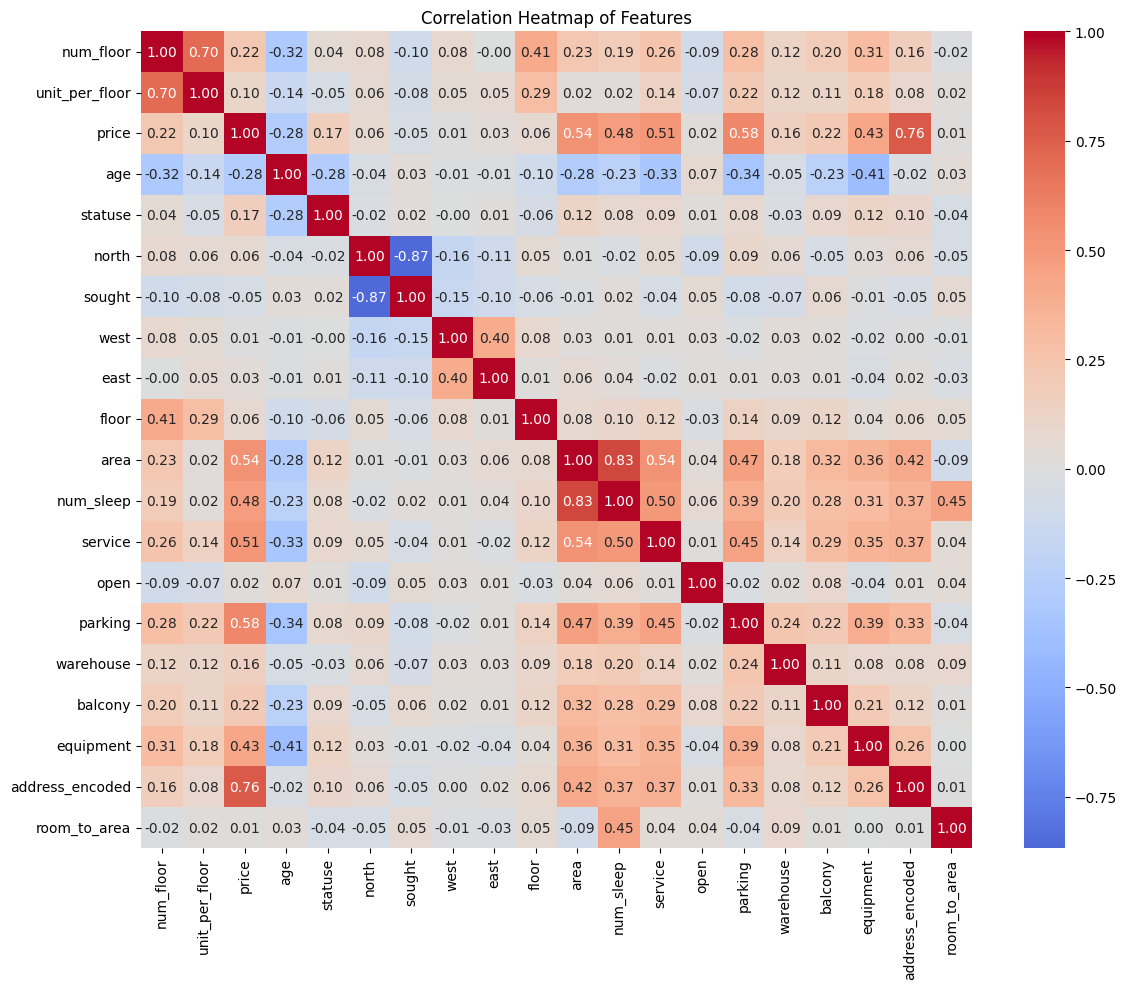

In [5]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Features')
plt.tight_layout()
plt.show()

# Price distribution

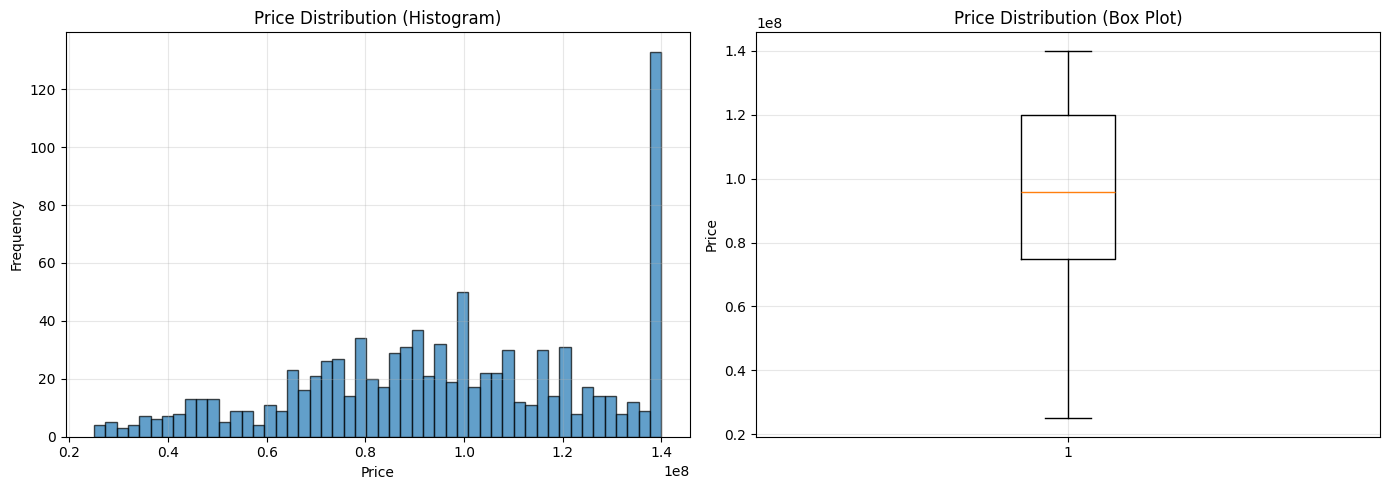

Price statistics:
count    9.510000e+02
mean     9.630043e+07
std      2.960411e+07
min      2.500000e+07
25%      7.500000e+07
50%      9.594828e+07
75%      1.200000e+08
max      1.400000e+08
Name: price, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution (Histogram)')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df['price'], vert=True)
axes[1].set_ylabel('Price')
axes[1].set_title('Price Distribution (Box Plot)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Price statistics:")
print(df['price'].describe())

# Feature importance based on correlation with price

Feature correlations with price:
price              1.000000
address_encoded    0.759660
parking            0.579264
area               0.540501
service            0.508912
num_sleep          0.478094
equipment          0.434286
num_floor          0.221412
balcony            0.218099
statuse            0.167079
warehouse          0.160948
unit_per_floor     0.103387
north              0.060684
floor              0.059949
east               0.032494
open               0.017039
room_to_area       0.011020
west               0.007550
sought            -0.046662
age               -0.284716
Name: price, dtype: float64


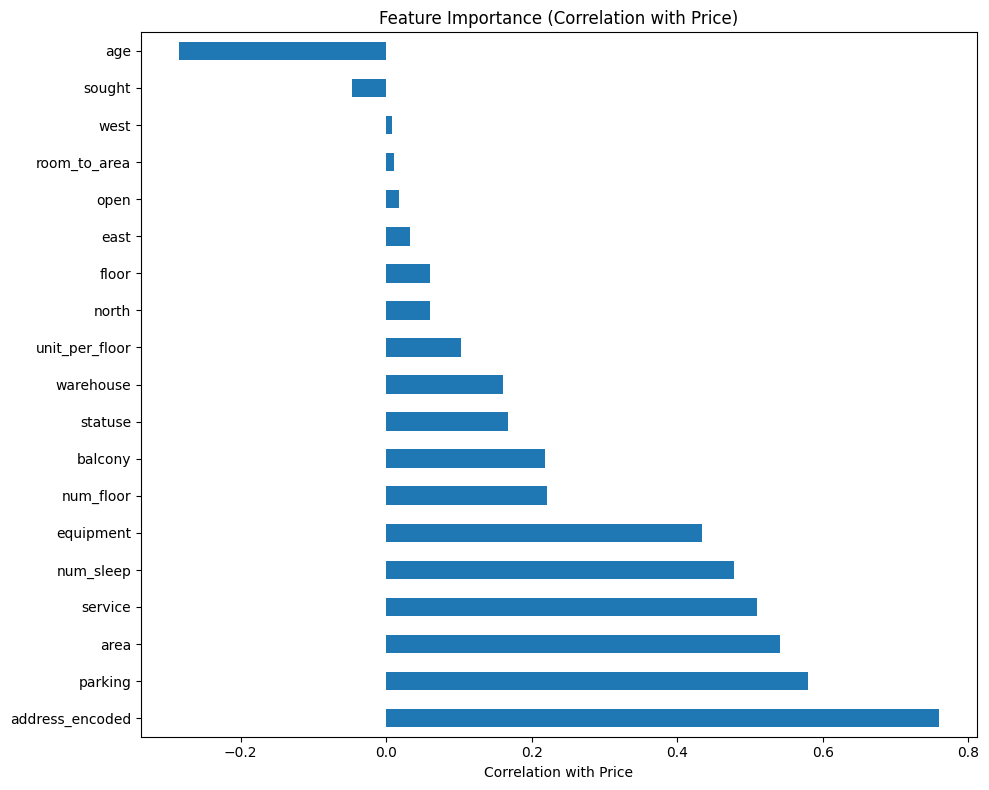

In [7]:
feature_correlations = df.corr()['price'].sort_values(ascending=False)
print("Feature correlations with price:")
print(feature_correlations)

plt.figure(figsize=(10, 8))
feature_correlations.drop('price').plot(kind='barh')
plt.xlabel('Correlation with Price')
plt.title('Feature Importance (Correlation with Price)')
plt.tight_layout()
plt.show()

# Separate features and target

In [8]:
X = df.drop('price', axis=1)
y = df['price']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (951, 19)
Target shape: (951,)

Feature columns:
['num_floor', 'unit_per_floor', 'age', 'statuse', 'north', 'sought', 'west', 'east', 'floor', 'area', 'num_sleep', 'service', 'open', 'parking', 'warehouse', 'balcony', 'equipment', 'address_encoded', 'room_to_area']


# Train test split

In [9]:
# Split data: 70% train, 15% validation, 15% test
X_train, X_temp, y_train,  y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 665
Validation set size: 143
Test set size: 143


# Scale features and target

In [10]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Convert to Tensor

In [12]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

print("Tensor shapes:")
print(X_train_tensor.shape, y_train_tensor.shape)

Tensor shapes:
torch.Size([665, 19]) torch.Size([665, 1])


## Model Architecture

In [13]:
class ManualRegresion(nn.Module):
    
    def __init__(self, input_size):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(64, 16),
            nn.ReLU(),
            
            nn.Linear(16, 8),
            nn.ReLU(),
            
            nn.Linear(8, 1)
        )
        
    def forward(self, x):
        return self.model(x)

In [14]:
input_size = X_train_tensor.shape[1]
torch.manual_seed(42)
model = ManualRegresion(input_size).to(device)

print("Input size:", input_size)
print(model)

Input size: 19
ManualRegresion(
  (model): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=8, bias=True)
    (6): ReLU()
    (7): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [15]:
MSE = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=1e-4
)

In [16]:
num_epochs = 10000
batch_size = 16

train_losses = []
val_losses = []

best_val_loss = float('inf')
patience = 500
patience_counter = 0
best_model_state = None

## Training Loop

In [17]:
for epoch in range(num_epochs):
    
    model.train()
    epoch_loss = 0
    
    for i in range(0, len(X_train_tensor), batch_size):
        
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]
        
        optimizer.zero_grad()
        
        outputs = model(batch_X)
        
        loss = MSE(outputs, batch_y)
        
        loss.backward()
        
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / (len(X_train_tensor)/batch_size)
    
    train_losses.append(avg_train_loss)
    
    
    model.eval()
    
    with torch.no_grad():
        
        val_outputs = model(X_val_tensor)
        val_loss = MSE(val_outputs, y_val_tensor)
        
        val_losses.append(val_loss.item())
    
    
    if val_loss < best_val_loss:
        
        best_val_loss = val_loss
        patience_counter = 0
        
        best_model_state = model.state_dict()
        
        torch.save(best_model_state, "best_model.pth")
        
    else:
        
        patience_counter += 1
        
        if patience_counter >= patience:
            
            print("Early stopping at epoch:", epoch)
            
            model.load_state_dict(best_model_state)
            
            break
    
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch 50 | Train Loss: 0.020176 | Val Loss: 0.019236
Epoch 100 | Train Loss: 0.019136 | Val Loss: 0.018633
Epoch 150 | Train Loss: 0.021734 | Val Loss: 0.018909
Epoch 200 | Train Loss: 0.018193 | Val Loss: 0.018199
Epoch 250 | Train Loss: 0.018611 | Val Loss: 0.017599
Epoch 300 | Train Loss: 0.019915 | Val Loss: 0.017712
Epoch 350 | Train Loss: 0.018847 | Val Loss: 0.017914
Epoch 400 | Train Loss: 0.019739 | Val Loss: 0.021568
Epoch 450 | Train Loss: 0.019216 | Val Loss: 0.020016
Epoch 500 | Train Loss: 0.017990 | Val Loss: 0.019795
Epoch 550 | Train Loss: 0.018530 | Val Loss: 0.019314
Epoch 600 | Train Loss: 0.018562 | Val Loss: 0.019965
Epoch 650 | Train Loss: 0.019109 | Val Loss: 0.019586
Epoch 700 | Train Loss: 0.018220 | Val Loss: 0.020241
Epoch 750 | Train Loss: 0.018025 | Val Loss: 0.019938
Early stopping at epoch: 759


## Trainig Plot

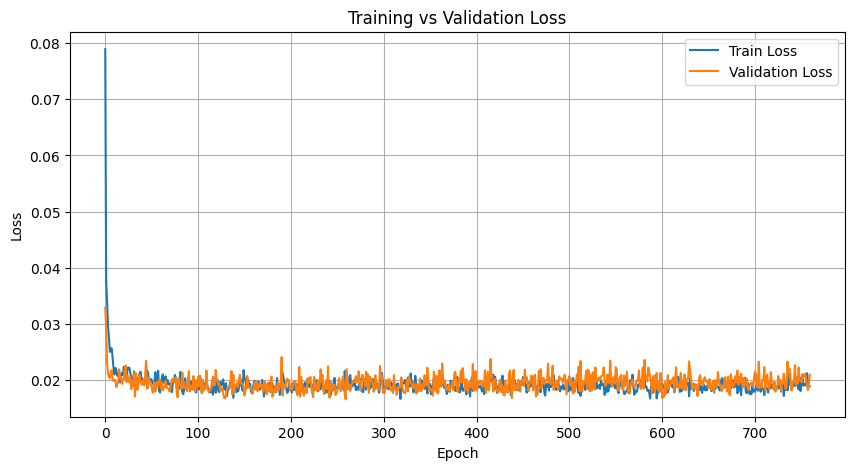

In [18]:
plt.figure(figsize=(10,5))

plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

## Save weights

In [19]:
model.load_state_dict(torch.load("best_model.pth"))

model.eval()

ManualRegresion(
  (model): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=8, bias=True)
    (6): ReLU()
    (7): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [20]:
with torch.no_grad():
    
    y_pred_scaled = model(X_test_tensor).cpu().numpy()

y_pred = scaler_y.inverse_transform(y_pred_scaled)

y_true = scaler_y.inverse_transform(y_test_tensor.cpu().numpy())

## Metrics

In [21]:
r2 = r2_score(y_true, y_pred)

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.8169335722923279
MAE: 10314378.0
RMSE: 13003693.710425511


## Plot after training model

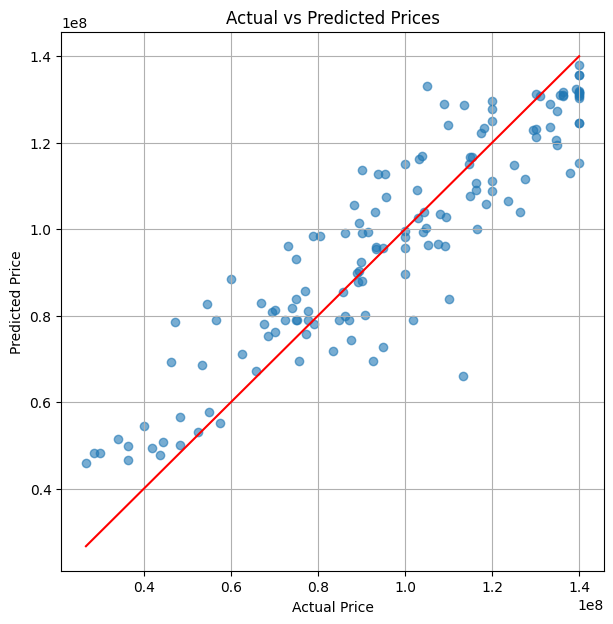

In [22]:
plt.figure(figsize=(7,7))

plt.scatter(y_true, y_pred, alpha=0.6)

plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         color="red")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.grid()

plt.show()

## Residual Plot


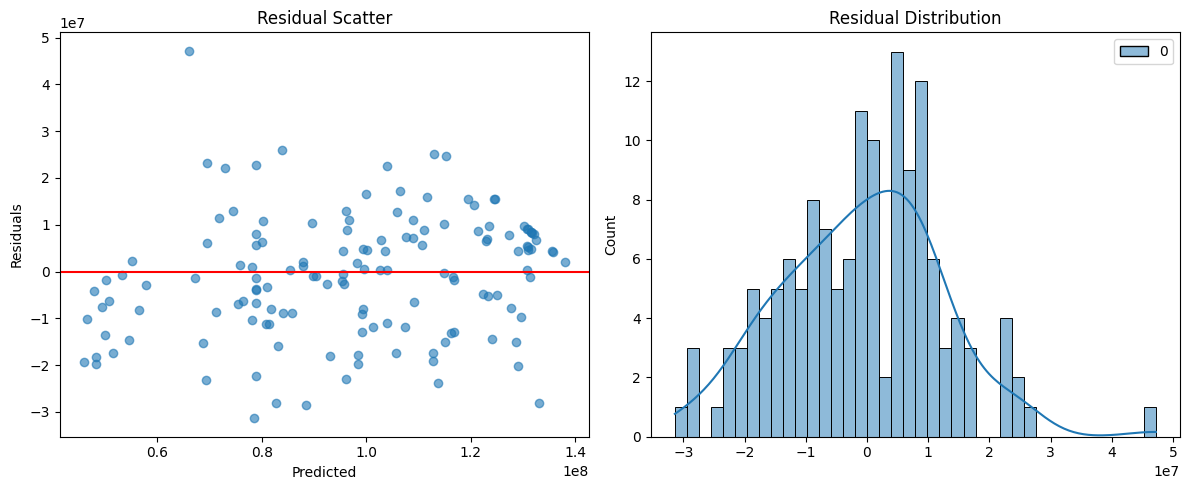

In [23]:
residuals = y_true - y_pred

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_pred,residuals,alpha=0.6)
plt.axhline(0,color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Scatter")

plt.subplot(1,2,2)
sns.histplot(residuals,bins=40,kde=True)
plt.title("Residual Distribution")

plt.tight_layout()
plt.show()